In [1]:
import joblib
import os
import sys
import yaml

import numpy as np
import pandas as pd

In [2]:
config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
protocol_cols = annot_dict["protocol_columns"]

In [3]:
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


In [12]:
all_runs = []

res_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop2p5_replicate"
# res_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official"
opt_modes_list = os.listdir(res_base_dir)

for opt_leaf_dir in opt_modes_list:
    opt_dir = os.path.join(res_base_dir, opt_leaf_dir)
    cts_list = os.listdir(opt_dir)

    for ct_leaf_dir in cts_list:
        ct_dir = os.path.join(opt_dir, ct_leaf_dir)
        runs_list = os.listdir(ct_dir)

        for run_leaf_dir in runs_list:
            run_dir = os.path.join(ct_dir, run_leaf_dir)
            csv_path = os.path.join(run_dir, "candidates.csv")            
            all_runs.append(
                {
                    "target_ct": ct_leaf_dir,
                    "run_id": run_leaf_dir,
                    "opt_id": opt_leaf_dir,
                    "csv_path": csv_path,
                }
            )


In [13]:
def load_run(run_dict):
    target_ct = run_dict["target_ct"]
    run_id = run_dict["run_id"]
    opt_id = run_dict["opt_id"]
    csv_path = run_dict["csv_path"]

    df = pd.read_csv(csv_path)
    df["run_id"] = run_id
    df["opt_id"] = opt_id
    df["target_ct"] = target_ct
    return df
    
n_jobs = 100
data = joblib.Parallel(n_jobs=n_jobs)(joblib.delayed(load_run)(run_dict) for run_dict in all_runs)
candidates_df = pd.concat(data, ignore_index=True)
candidates_df

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,EryPro:2026-06-26_04-11-58_cee7e426:0,12.124698,2.182126,84.65543,0.000000,0.862212,0.000000,0.000000,0.006725,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EryPro:2026-06-26_04-11-58_cee7e426:1,2.807606,0.016716,289.35630,175.749700,0.000000,0.000000,116.696170,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EryPro:2026-06-26_04-11-58_cee7e426:2,10.091269,2.569805,550.93555,782.041000,0.045200,47.781437,0.066810,0.000000,0.001518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EryPro:2026-06-26_04-11-58_cee7e426:3,9.844760,2.468653,774.40030,0.063012,0.552813,47.939167,0.052818,0.296393,0.015844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EryPro:2026-06-26_04-11-58_cee7e426:4,9.687686,2.489527,824.40380,1212.362300,0.025199,56.669476,0.000000,0.032299,0.015634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90945,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:45,10.852804,2.487143,551.91125,773.857000,0.000000,48.539486,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90946,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:46,11.335658,2.366785,1005.68230,578.002700,0.000000,24.263077,0.094563,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90947,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:47,10.607610,1.946655,742.47614,1444.148200,0.000000,39.061016,0.000000,0.000000,1.770090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90948,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:48,10.221303,2.617736,347.98157,645.587950,0.000000,43.864124,0.000000,0.000000,0.040813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 90950 ---
			 --- Number Currently Accepted Solutions 81288 ---
			 --- Number of Solution Satisfying Upper Bound 81288 ---
			 --- Number of Solution Satisfying Lower Bound 90950 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 81288 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 90950 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 81288 ---
			 --- Number Currently Accepted Solutions 75268 ---
			 --- Number of Solution Satisfying Upper Bound 83221 ---
			 --- Number of Solution Satisfying Lower Bound 90950 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 75268 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 81288 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

In [15]:
filtering_col = "passes_constraints:all"
passes_constraints_mask = candidates_df[filtering_col]
filtered_candidates_df = candidates_df[passes_constraints_mask]

filtered_concs_orig = filtered_candidates_df[protocol_cols].astype(float)
filtered_concs = pd.DataFrame(np.log1p(filtered_concs_orig.values), columns=filtered_concs_orig.columns, index=filtered_concs_orig.index)
filtered_concs

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
2,2.406158,1.272511,6.313431,6.663185,0.044209,3.887350,0.064673,0.000000,0.001517,0.000000,3.009555,2.949782
3,2.383682,1.243766,6.653379,0.061106,0.440068,3.890578,0.051471,0.259586,0.015720,0.018746,2.910058,2.478929
6,1.517891,0.160850,4.690111,4.477363,0.000000,0.000000,4.572103,0.000000,0.000000,0.040535,3.031270,2.681673
8,2.289374,1.207637,6.487219,0.190455,0.615906,3.775037,0.080933,0.216432,0.078140,0.063087,2.849716,2.899871
9,2.316494,1.223133,4.283173,5.118690,0.000000,3.056419,0.000000,0.000000,0.000000,0.089671,2.963152,2.901428
...,...,...,...,...,...,...,...,...,...,...,...,...
90938,2.465172,1.302120,5.796405,7.090523,0.020679,3.978345,0.000000,0.000000,0.000000,1.556496,3.005301,2.648480
90940,2.266412,1.142267,4.235482,0.000000,0.363604,3.824336,0.043603,0.212167,0.000000,0.000000,2.949803,2.827225
90942,2.453591,0.916794,6.271259,6.811771,0.000000,3.966513,1.158396,0.000000,0.000000,1.856341,3.029384,2.635851
90945,2.472564,1.249083,6.315198,6.652678,0.000000,3.902770,0.000000,0.000000,0.000000,0.000000,2.805769,2.757208


# Monocytes.

In [16]:
cd14_mask = filtered_candidates_df["target_ct"] == "CD14Mono"
cd16_mask = filtered_candidates_df["target_ct"] == "CD16Mono"

n_cd14 = cd14_mask.sum()
n_cd16 = cd16_mask.sum()
print(f"Passing experimental constraints -> CD14: {n_cd14}, CD16: {n_cd16}")

cd14_df = filtered_candidates_df.loc[cd14_mask]
cd16_df = filtered_candidates_df.loc[cd16_mask]

tgt_enrichment = 0.1
cd14_tgt_mask = cd14_df["CD14Mono_prop"] >= tgt_enrichment
cd16_tgt_mask = cd16_df["CD16Mono_prop"] >= tgt_enrichment

n_cd14_enrichment = cd14_tgt_mask.sum()
n_cd16_enrichment = cd16_tgt_mask.sum()
print(f"Passing target enrichment -> CD14: {n_cd14_enrichment}, CD16: {n_cd16_enrichment}")


Passing experimental constraints -> CD14: 8626, CD16: 11377
Passing target enrichment -> CD14: 0, CD16: 0


## Mgk.

In [17]:
mgk_mask = filtered_candidates_df["target_ct"] == "late_MgkPro"

n_mgk = mgk_mask.sum()
print(f"Passing experimental constraints -> Mgk: {n_mgk}")

mgk_df = filtered_candidates_df.loc[mgk_mask]

tgt_enrichment = 0.1
mgk_tgt_mask = mgk_df["late_MgkPro_prop"] >= tgt_enrichment

n_mgk_enrichment = mgk_tgt_mask.sum()
print(f"Passing target enrichment -> Mgk: {n_mgk_enrichment}")


Passing experimental constraints -> Mgk: 18181
Passing target enrichment -> Mgk: 410


## Ery.

In [18]:
ery_mask = filtered_candidates_df["target_ct"] == "EryPro"

n_ery = ery_mask.sum()
print(f"Passing experimental constraints -> EryPro: {n_ery}")

ery_df = filtered_candidates_df.loc[ery_mask]

tgt_enrichment = 0.1
ery_tgt_mask = ery_df["EryPro_prop"] >= tgt_enrichment

n_ery_enrichment = ery_tgt_mask.sum()
print(f"Passing target enrichment -> EryPro: {n_ery_enrichment}")


Passing experimental constraints -> EryPro: 9498
Passing target enrichment -> EryPro: 3843


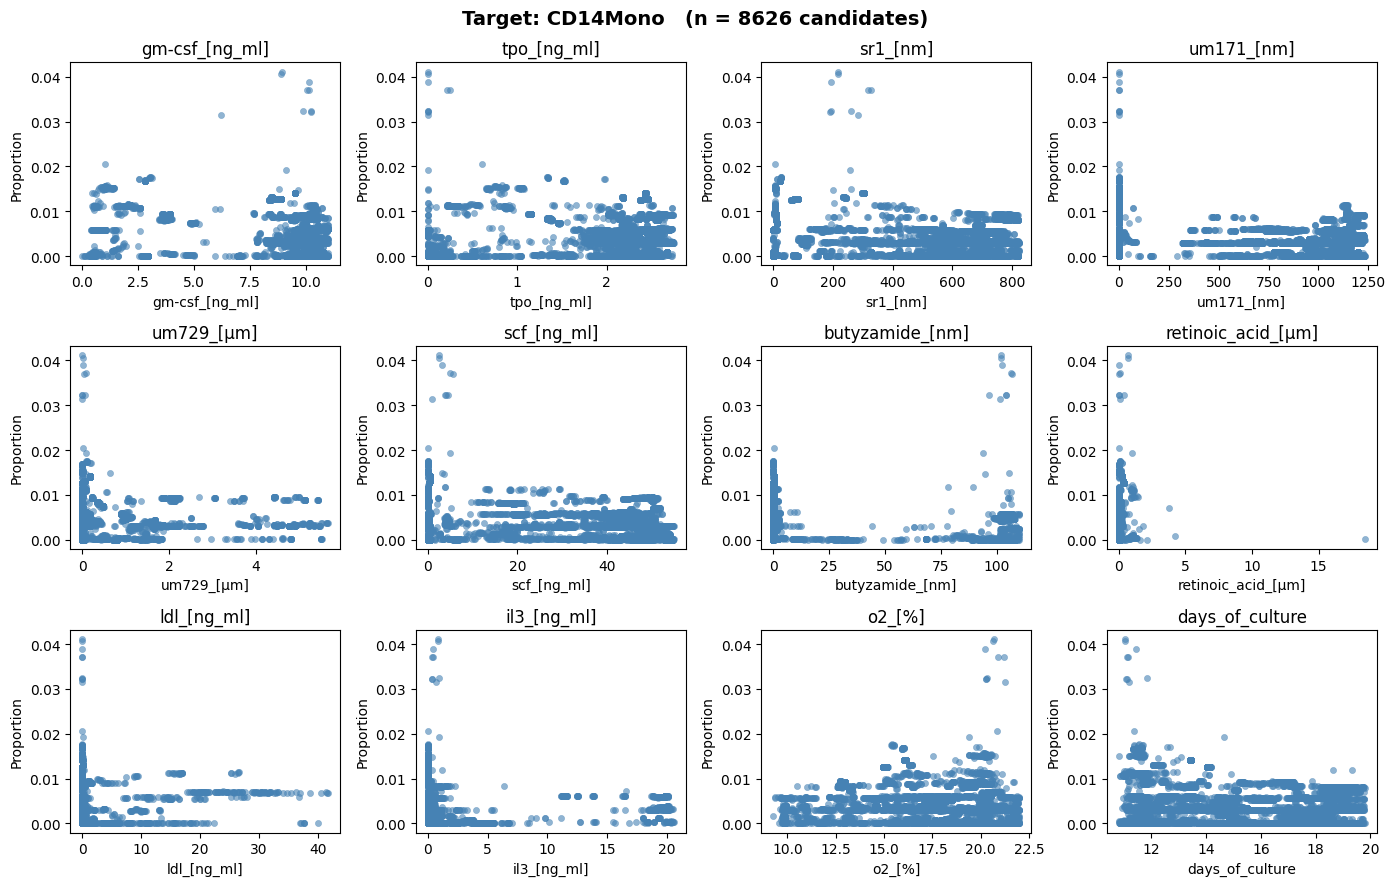

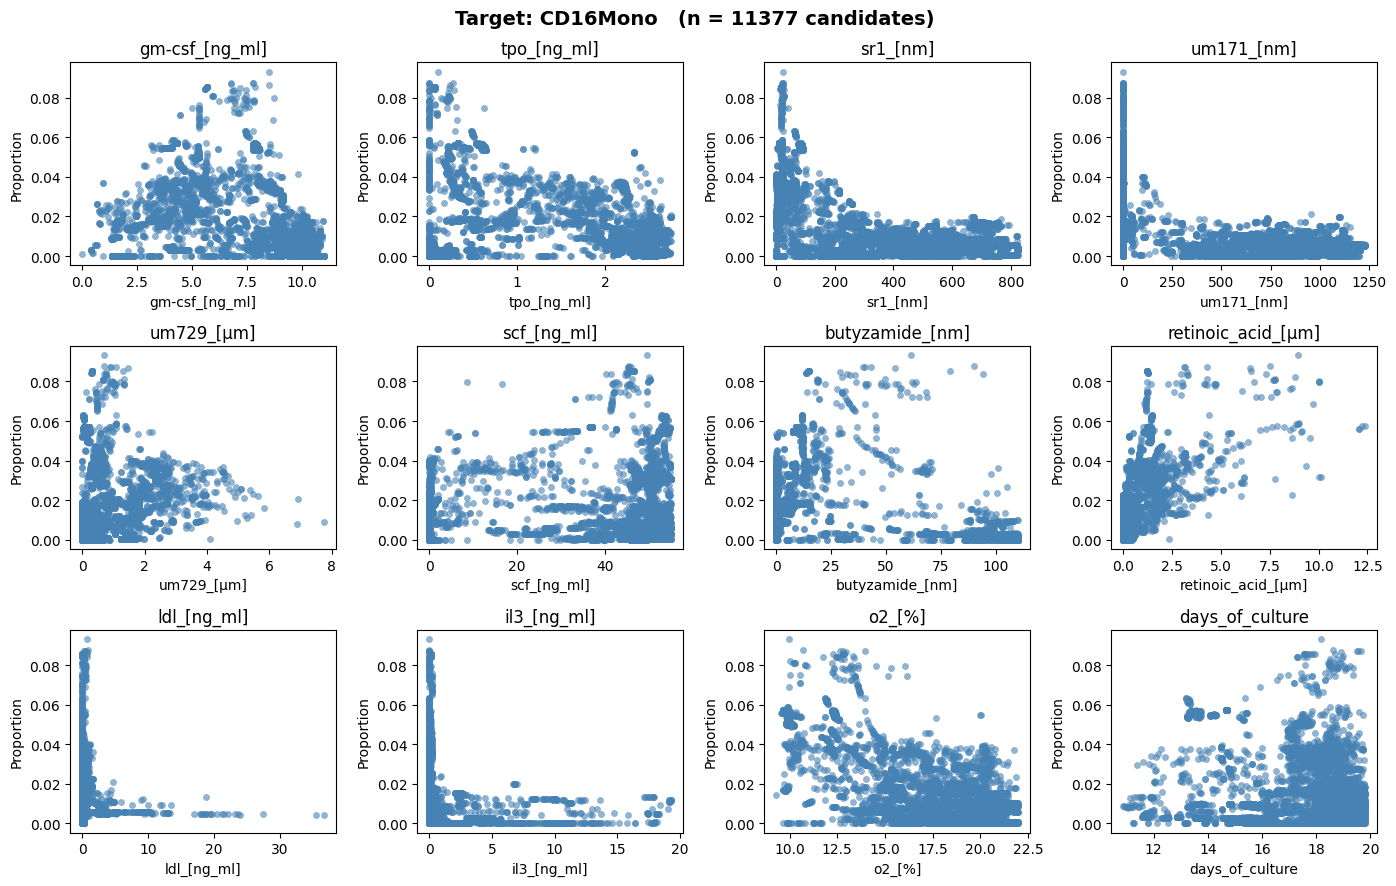

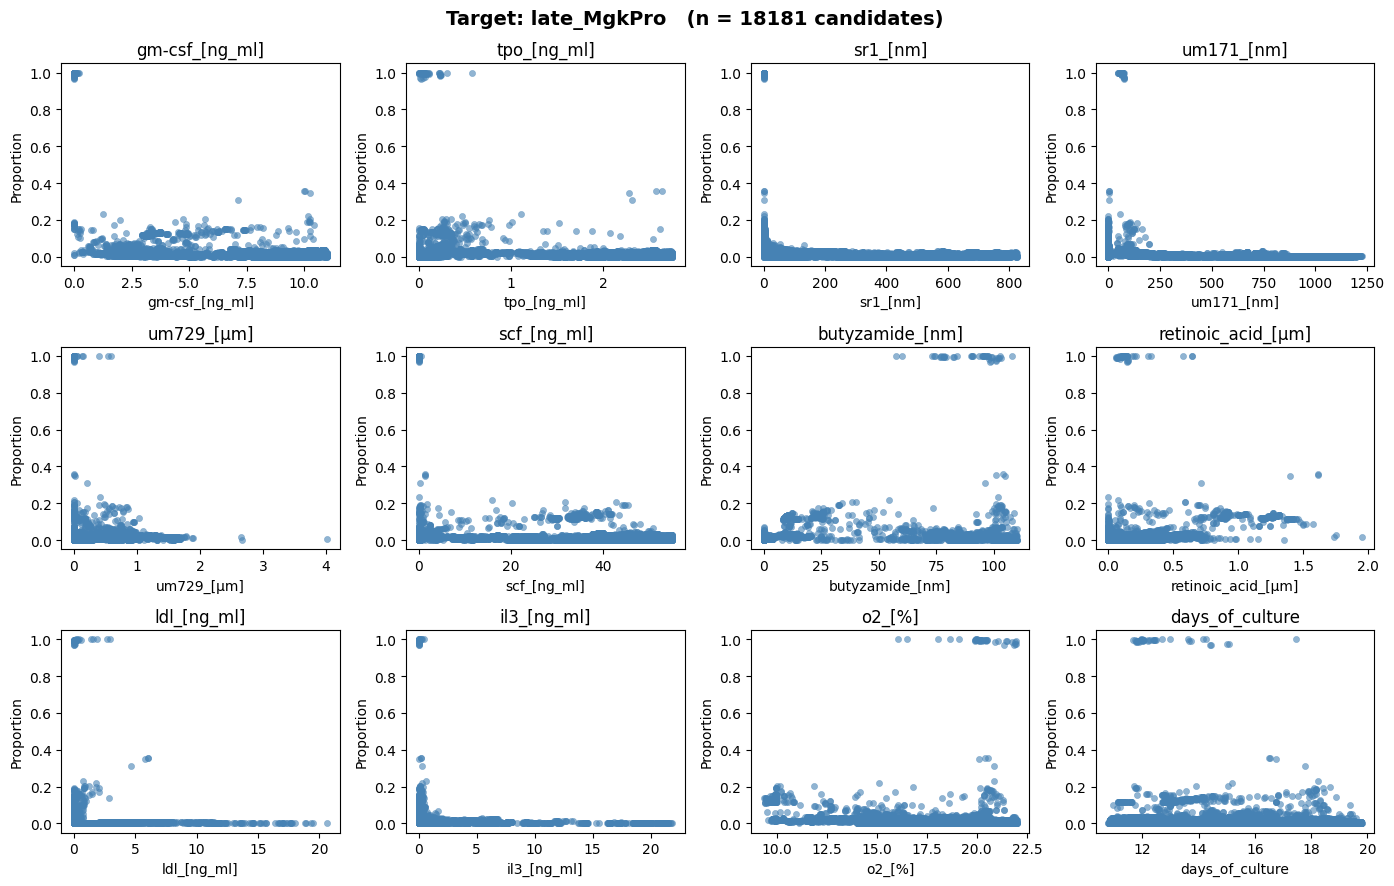

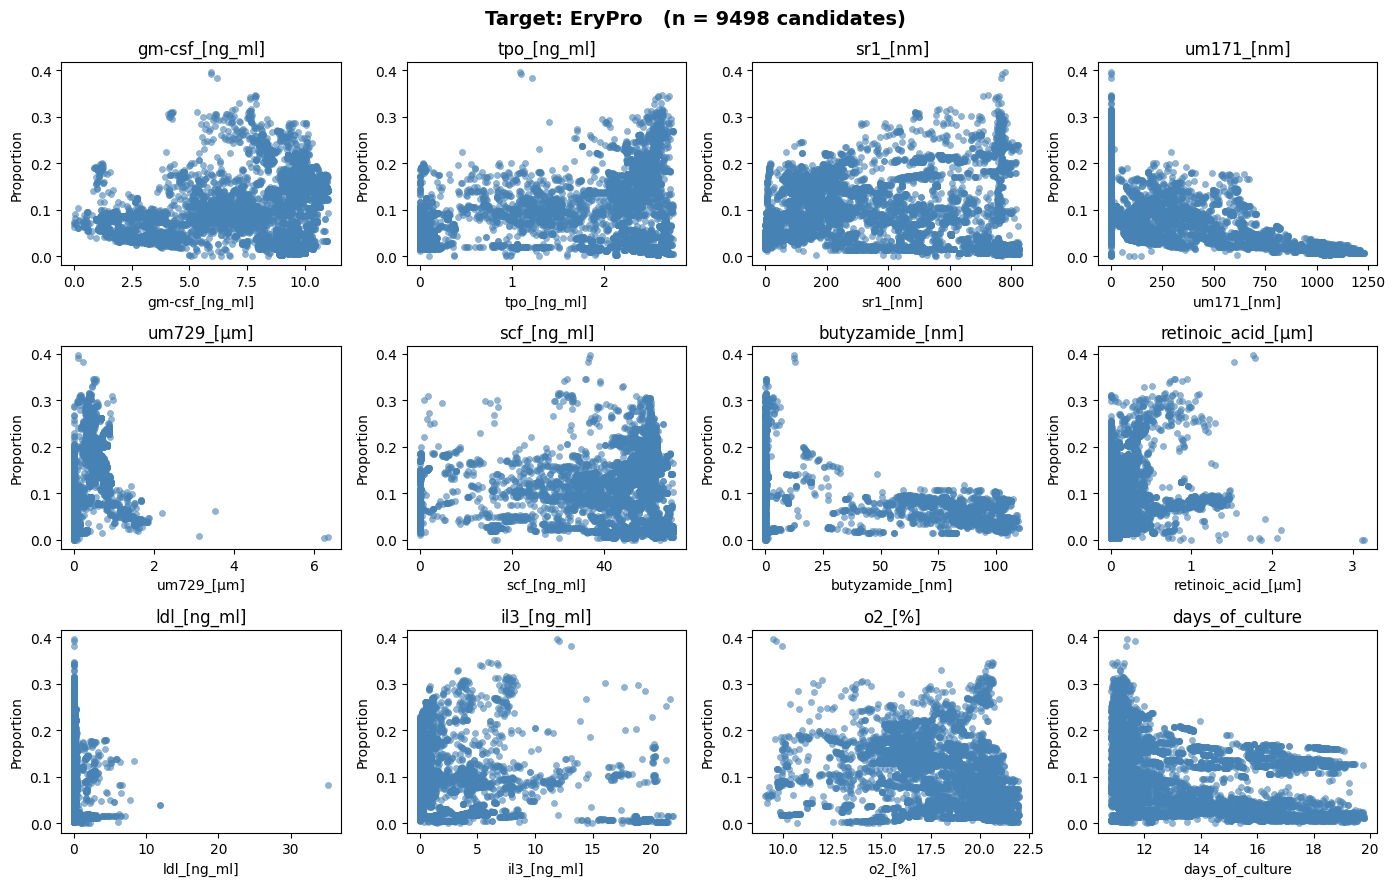

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ---------- 1. Map target_ct → proportion column ----------
ct_to_prop_col = {
    "CD14Mono":    "CD14Mono_prop",
    "CD16Mono":    "CD16Mono_prop",
    "late_MgkPro": "late_MgkPro_prop",
    "EryPro":      "EryPro_prop"
}

# ---------- 2. Molecules to plot ----------
molecules = protocol_cols   # from config

# ---------- 3. Loop over each cell type ----------
for ct, prop_col in ct_to_prop_col.items():
    # Subset: only this cell type's filtered candidates
    ct_df = filtered_candidates_df[filtered_candidates_df["target_ct"] == ct].copy()
    if len(ct_df) == 0:
        print(f"No candidates for {ct}, skipping.")
        continue

    # Add target proportion
    ct_df["target_proportion"] = ct_df[prop_col]

    # ----- Subplot grid -----
    n_mols = len(molecules)
    n_cols = 4                # you can adjust
    n_rows = math.ceil(n_mols / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols*3.5, n_rows*3),
                             squeeze=False)

    for i, mol in enumerate(molecules):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        sns.scatterplot(
            data=ct_df,
            x=mol,
            y="target_proportion",
            ax=ax,
            alpha=0.6,
            edgecolor=None,
            color="steelblue",
            s=20
        )
        ax.set_xlabel(mol)
        ax.set_ylabel("Proportion")
        ax.set_title(mol)

    # Hide any unused subplots
    for j in range(i+1, n_rows*n_cols):
        row = j // n_cols
        col = j % n_cols
        axes[row, col].set_visible(False)

    fig.suptitle(f"Target: {ct}   (n = {len(ct_df)} candidates)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()